<div style="padding: 20px; background-color: #f8f9fa; border-left: 10px solid #007bff; border-radius: 5px;">
    <h1 style="color: #007bff;">🏠 Post-Pandemic Housing Market Analysis</h1>
    <h3>Preprocessing & Feature Engineering Pipeline</h3>
    <p><b>Group 4 | 3CSE Machine Learning</b></p>
    <hr>
    <p><b>Objective:</b> This notebook processes Zillow Real Estate data to investigate non-linear determinants of housing prices during the WFH (Work From Home) era. We aim to bridge hyper-local price data with structural economic indicators to prepare a high-fidelity tensor for <b>Multiple Linear Regression</b> and <b>Decision Tree (CART)</b> modeling.</p>
</div>


## 🛠️ Environment Setup

In [3]:
import pandas as pd
import numpy as np
# from google.colab import drive
import os

## 📂 Data Acquisition

In [4]:
# 1. Mount Drive
# drive.mount('/content/drive',force_remount=True)

# 2. Define your specific path
# Pro-tip: Use the full string exactly as it appears in Colab's file explorer
base_path = 'Dataset/'

# 3. List of your files (using the exact names you provided)
files = {
    'zhvi': 'metro_zhvi.csv',
    'rent': 'metro_zori.csv',
    'for_sale': 'metro_forsale.csv',
    'new_listings': 'metro_new_listings.csv',
    'days_pending': 'metro_med_days_to_pending.csv',
    'price_cuts': 'metro_shrlist_prcut.csv',
    'income_needed': 'metro_new_homeowner_income_needed.csv',
    'zhvi_1b': 'metro_zhvi_1_bdrm.csv',
    'zhvi_2b': 'metro_zhvi_2_bdrm.csv',
    'zhvi_3b': 'metro_zhvi_3_bdrm.csv',
    'zhvi_4b': 'metro_zhvi_4_bdrm.csv',
    'zhvi_5b': 'metro_zhvi_5plus_bdrm.csv',
    'market_heat_index': 'metro_market_heat_index.csv',
    'new_homeowner_affordability': 'metro_new_homeowner_affordability.csv'
}

In [5]:
# 4. Load dataframes into a dictionary
dfs = {}
print("--- Starting Data Load ---")
for key, filename in files.items():
    full_path = os.path.join(base_path, filename)
    if os.path.exists(full_path):
        dfs[key] = pd.read_csv(full_path)
        print(f"✅ Success: {key} loaded. Shape: {dfs[key].shape}")
    else:
        print(f"❌ Error: File not found at {full_path}")

--- Starting Data Load ---
✅ Success: zhvi loaded. Shape: (895, 320)
✅ Success: rent loaded. Shape: (719, 140)
✅ Success: for_sale loaded. Shape: (928, 102)
✅ Success: new_listings loaded. Shape: (927, 102)
✅ Success: days_pending loaded. Shape: (769, 102)
✅ Success: price_cuts loaded. Shape: (928, 102)
✅ Success: income_needed loaded. Shape: (390, 176)
✅ Success: zhvi_1b loaded. Shape: (671, 320)
✅ Success: zhvi_2b loaded. Shape: (851, 320)
✅ Success: zhvi_3b loaded. Shape: (884, 320)
✅ Success: zhvi_4b loaded. Shape: (855, 320)
✅ Success: zhvi_5b loaded. Shape: (758, 320)
✅ Success: market_heat_index loaded. Shape: (928, 104)
✅ Success: new_homeowner_affordability loaded. Shape: (390, 176)


## ⚙️ Data Reshaping & Structural Alignment

In [6]:
def process_and_merge(dfs):
    # 1. THE MELT: Transforming horizontal date columns into vertical rows
    melted_dfs = {}
    id_vars = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']

    print("--- Reshaping Data ---")
    for key, df in dfs.items():
        # Identify date columns (they start with '20' or '19')
        date_cols = [col for col in df.columns if col.startswith(('20', '19'))]

        # Melt the dataframe
        df_long = df.melt(id_vars=id_vars, value_vars=date_cols,
                          var_name='Date', value_name=key)

        # Convert Date string to datetime objects for accurate merging
        df_long['Date'] = pd.to_datetime(df_long['Date'])
        melted_dfs[key] = df_long
        print(f"Reshaped {key}...")

    # 2. THE MASTER MERGE: Stitching all 12 tables together
    # We start with 'zhvi' as our base anchor
    master_df = melted_dfs['zhvi']

    print("\n--- Merging Tables ---")
    # List of keys to merge (excluding the anchor 'zhvi')
    other_keys = [k for k in melted_dfs.keys() if k != 'zhvi']

    for key in other_keys:
        # We only need RegionID, Date, and the actual Data Value for the merge
        subset = melted_dfs[key][['RegionID', 'Date', key]]
        master_df = pd.merge(master_df, subset, on=['RegionID', 'Date'], how='left')
        print(f"Merged {key} into master...")

    # 3. FEATURE ENGINEERING: Creating non-linear proxies
    print("\n--- Engineering Features ---")

    # Space Premium: Ratio of 4-bedroom to 2-bedroom prices
    # Formula: $Space\_Premium = \frac{ZHVI_{4BR}}{ZHVI_{2BR}}$
    master_df['space_premium'] = master_df['zhvi_4b'] / master_df['zhvi_2b']

    # Era Toggle: Categorizing the market shift (Interest Rate Hike Era)
    # 0 = Pandemic/Low-Rate, 1 = Post-Pandemic/High-Rate
    master_df['is_post_pandemic'] = (master_df['Date'] >= '2022-04-01').astype(int)

    # 4. CLEANING: Handling missing values and sorting
    print("--- Cleaning & Filling Gaps ---")
    master_df = master_df.sort_values(['RegionID', 'Date'])

    # Forward-fill (carry last known value) then backward-fill within each Metro group
    master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

    # Drop rows that are still NaN (where no data exists for that Metro at all)
    master_df.dropna(inplace=True)

    return master_df

# Execute the pipeline
master_df = process_and_merge(dfs)
print(f"\nFinal Master Dataframe Shape: {master_df.shape}")

--- Reshaping Data ---
Reshaped zhvi...
Reshaped rent...
Reshaped for_sale...
Reshaped new_listings...
Reshaped days_pending...
Reshaped price_cuts...
Reshaped income_needed...
Reshaped zhvi_1b...
Reshaped zhvi_2b...
Reshaped zhvi_3b...
Reshaped zhvi_4b...
Reshaped zhvi_5b...
Reshaped market_heat_index...
Reshaped new_homeowner_affordability...

--- Merging Tables ---
Merged rent into master...
Merged for_sale into master...
Merged new_listings into master...
Merged days_pending into master...
Merged price_cuts into master...
Merged income_needed into master...
Merged zhvi_1b into master...
Merged zhvi_2b into master...
Merged zhvi_3b into master...
Merged zhvi_4b into master...
Merged zhvi_5b into master...
Merged market_heat_index into master...
Merged new_homeowner_affordability into master...

--- Engineering Features ---
--- Cleaning & Filling Gaps ---


/tmp/ipykernel_329288/576788114.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)



Final Master Dataframe Shape: (112455, 22)


/tmp/ipykernel_329288/576788114.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('RegionID').apply(lambda x: x.ffill().bfill()).reset_index(drop=True)


In [7]:
master_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,zhvi,rent,for_sale,new_listings,...,income_needed,zhvi_1b,zhvi_2b,zhvi_3b,zhvi_4b,zhvi_5b,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic
945,394299,251,"Abilene, TX",msa,TX,2000-01-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
946,394299,251,"Abilene, TX",msa,TX,2000-02-29,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
947,394299,251,"Abilene, TX",msa,TX,2000-03-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
948,394299,251,"Abilene, TX",msa,TX,2000-04-30,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0
949,394299,251,"Abilene, TX",msa,TX,2000-05-31,110160.691527,794.734504,856.0,233.0,...,26823.496846,43875.104523,62226.945988,114218.361478,197258.479399,241278.729993,42.0,0.19137,3.169985,0


## 📊 EXPLORATORY DATA ANALYSIS

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 📊 1. Distribution of Home Values (ZHVI)

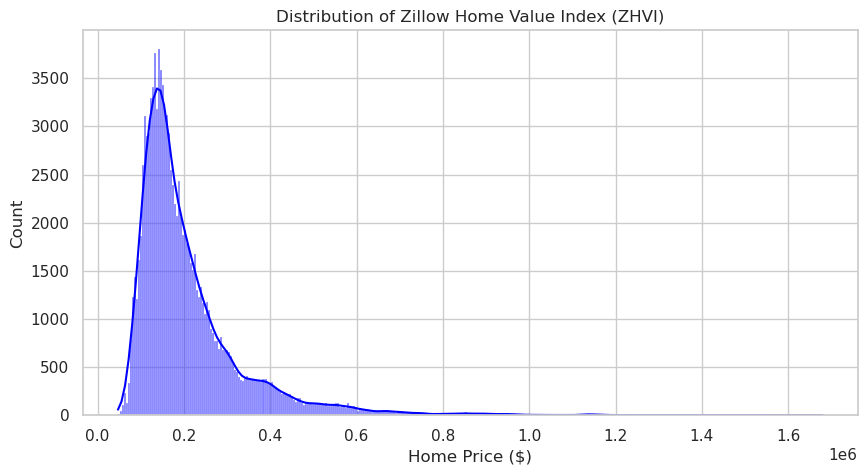

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(master_df['zhvi'], kde=True, color='blue')
plt.title('Distribution of Zillow Home Value Index (ZHVI)')
plt.xlabel('Home Price ($)')
plt.show()

### 🌡️ 2. Feature Correlation Matrix

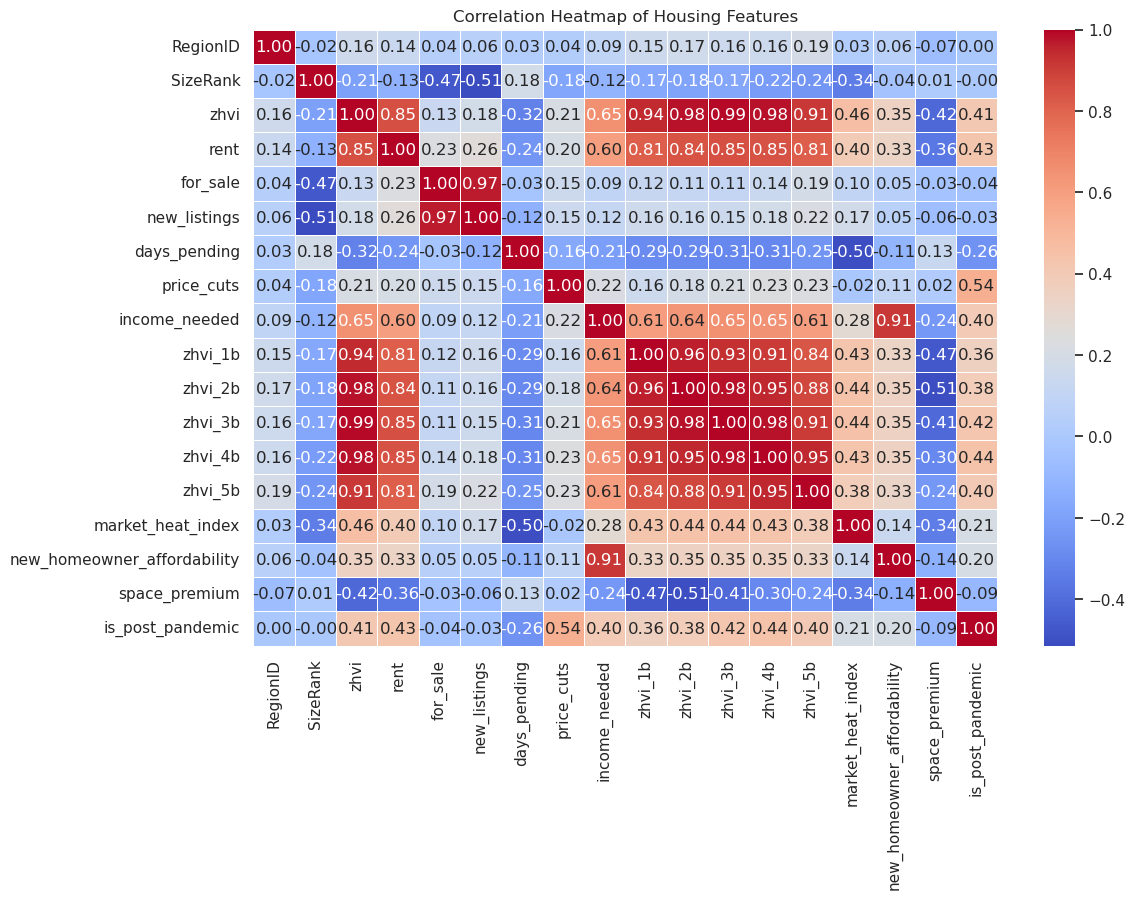

In [11]:
# Select only numerical columns for correlation
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
corr = master_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

### 🏢 3. The "Space Premium" Trend

/tmp/ipykernel_329288/1823257848.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)


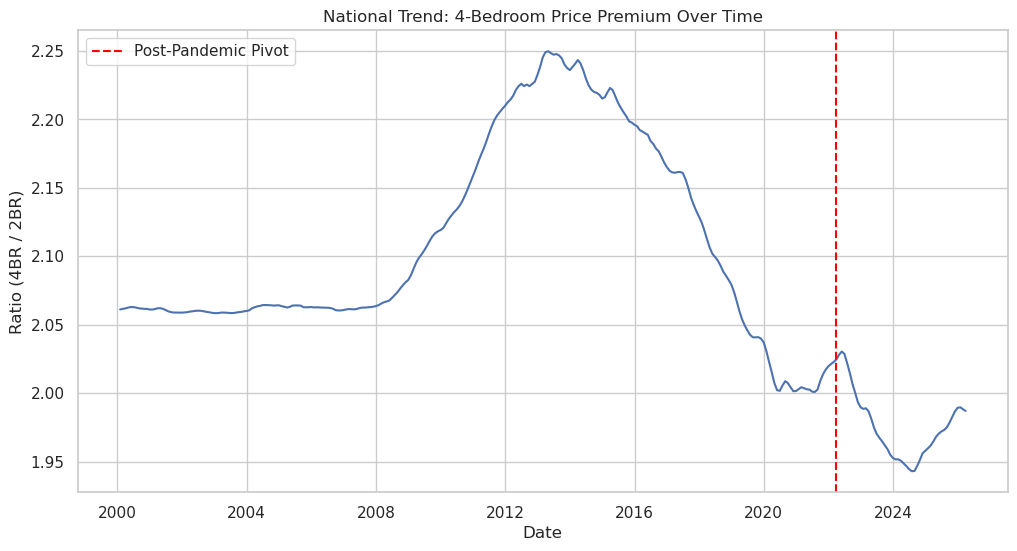

In [12]:
sns.lineplot(data=master_df, x='Date', y='space_premium', ci=None)
plt.axvline(pd.to_datetime('2022-04-01'), color='red', linestyle='--', label='Post-Pandemic Pivot')
plt.title('National Trend: 4-Bedroom Price Premium Over Time')
plt.ylabel('Ratio (4BR / 2BR)')
plt.legend()
plt.show()

## 🛠️ Section 2: Feature Encoding & Chronological Splitting
We apply **Label Encoding** to State names and **One-Hot Encoding** to Region types. To prevent data leakage, we use a chronological split (80/20) rather than a random shuffle.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

# 1. Sort by date first (Essential for time-series)
master_df = master_df.sort_values('Date')

# 2. Set a cut-off date for 'Post-Pandemic' exposure
split_date = '2023-01-01'
train_df = master_df[master_df['Date'] < split_date].copy()
test_df = master_df[master_df['Date'] >= split_date].copy()

# --- NEW: Safe Target Encoding Implementation ---
# Calculate means from training set only to prevent leakage
state_target_means = train_df.groupby('StateName')['zhvi'].mean()

# Map the means to create the 'state_encoded' feature
train_df['state_encoded'] = train_df['StateName'].map(state_target_means)
test_df['state_encoded'] = test_df['StateName'].map(state_target_means)

# Handle unseen states in the test set using the global training mean
global_train_mean = train_df['zhvi'].mean()
test_df['state_encoded'] = test_df['state_encoded'].fillna(global_train_mean)
# ------------------------------------------------

# 3. Define X and y
# Note: 'StateName' is dropped, but our new 'state_encoded' is NOT in this list, so it stays.
cols_to_drop = [
    'RegionID', 'RegionName', 'Date', 'RegionType', 'StateName', 'SizeRank',
    'zhvi', 'zhvi_1b', 'zhvi_2b', 'zhvi_3b', 'zhvi_4b', 'zhvi_5b',
    'new_listings', 'income_needed'
]

X_train_raw = train_df.drop(columns=cols_to_drop)
X_test_raw = test_df.drop(columns=cols_to_drop)
y_train = train_df['zhvi']
y_test = test_df['zhvi']

print(f"Training on data up to {train_df['Date'].max()}")
print(f"Testing on data from {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Feature count: {X_train_raw.shape[1]} (New feature 'state_encoded' included)")

Training on data up to 2022-12-31 00:00:00
Testing on data from 2023-01-31 00:00:00 to 2026-03-31 00:00:00
Feature count: 9 (New feature 'state_encoded' included)


In [14]:
# 1. Standardization (Mean=0, Variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

# 2. Export to Google Drive
export_folder = os.path.join(base_path, 'Model_Ready_Exports')
if not os.path.exists(export_folder): os.makedirs(export_folder)

sets = {
    'X_train.parquet': X_train, 'X_test.parquet': X_test,
    'y_train.parquet': y_train.to_frame(), 'y_test.parquet': y_test.to_frame()
}

for name, data in sets.items():
    data.to_parquet(os.path.join(export_folder, name), index=False)

# Save Scaler and Label Mapping
joblib.dump(scaler, os.path.join(export_folder, 'feature_scaler.pkl'))

print(f"✨ Successfully exported 4 datasets and scaler to: {export_folder}")

✨ Successfully exported 4 datasets and scaler to: Dataset/Model_Ready_Exports


In [16]:
# ==========================================
# Environment Setup & Data Ingestion
# ==========================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

# For Reproducibility
np.random.seed(42)

# Path to the model-ready data exports (relative to this notebook)
dataset_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Dataset', 'Model_Ready_Exports')

print("=" * 60)
print("LOADING DATA & APPLYING TARGET TRANSFORMATION")
print("=" * 60)

try:
    # Load the datasets
    X_train = pd.read_parquet(os.path.join(dataset_path, 'X_train.parquet'))
    X_test = pd.read_parquet(os.path.join(dataset_path, 'X_test.parquet'))
    y_train = pd.read_parquet(os.path.join(dataset_path, 'y_train.parquet'))
    y_test = pd.read_parquet(os.path.join(dataset_path, 'y_test.parquet'))

    # Load scaler in case we need to inverse transform features later
    scaler = joblib.load(os.path.join(dataset_path, 'feature_scaler.pkl'))

    # Extract the 1D series from the y dataframes
    y_train_raw = y_train.squeeze()
    y_test_raw = y_test.squeeze()

    # Apply log1p transformation to the target variables
    y_train_log = np.log1p(y_train_raw)
    y_test_log = np.log1p(y_test_raw)

    print("✅ Datasets loaded successfully!")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train_log shape: {y_train_log.shape}")

    print("\nTarget Variable (zhvi) Summary:")
    print(f"Original y_train Mean: ${y_train_raw.mean():,.2f}")
    print(f"Log-Transformed y_train Mean: {y_train_log.mean():.4f}")

    # Display the first few rows of our training features
    print("\nFirst 5 rows of X_train:")
    display(X_train.head())

except Exception as e:
    print(f"Error loading files: {e}")
    print("Please double-check the 'dataset_path' variable.")

LOADING DATA & APPLYING TARGET TRANSFORMATION
✅ Datasets loaded successfully!
X_train shape: (98532, 9)
X_test shape: (13923, 9)
y_train_log shape: (98532,)

Target Variable (zhvi) Summary:
Original y_train Mean: $193,366.02
Log-Transformed y_train Mean: 12.0586

First 5 rows of X_train:


,rent,for_sale,days_pending,price_cuts,market_heat_index,new_homeowner_affordability,space_premium,is_post_pandemic,state_encoded
0,-0.786191,-0.348168,0.233897,0.129621,-0.091809,-0.204989,2.007224,-0.183597,-0.627317
1,-0.591568,-0.391177,2.527199,-0.890090,-1.169172,-0.220649,-0.127020,-0.183597,0.204456
2,-0.192740,0.944134,-1.107468,0.251143,0.529746,-0.343586,0.190462,-0.183597,-0.333845
3,-0.319452,-0.098773,-0.242071,0.493899,0.405435,-0.218287,-0.322654,-0.183597,2.712180
4,-1.097279,-0.374623,-0.415150,-0.513307,0.032502,-0.253359,0.453756,-0.183597,-0.627317


In [17]:
# ==========================================
# Train Multiple Linear Regression
# ==========================================

print("=" * 60)
print("TRAINING MULTIPLE LINEAR REGRESSION")
print("=" * 60)

# Initialize the model
mlr_model = LinearRegression()

# Fit the model using training set (predicting the log-transformed target)
mlr_model.fit(X_train, y_train_log)

# Extract and display what the model learned
print(f"Intercept (Beta_0): {mlr_model.intercept_:.4f}\n")

print("Feature Coefficients (Beta_1 to Beta_n):")
print("Note: Because features were standardized, larger absolute values indicate stronger impact.\n")

# Zip the column names with the coefficients for easy reading
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': mlr_model.coef_
})

# Sort by absolute value to see which features have the strongest impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1).reset_index(drop=True)

display(coefficients)

TRAINING MULTIPLE LINEAR REGRESSION
Intercept (Beta_0): 12.0586

Feature Coefficients (Beta_1 to Beta_n):
Note: Because features were standardized, larger absolute values indicate stronger impact.



,Feature,Coefficient
0,rent,0.205389
1,market_heat_index,0.088828
2,state_encoded,0.084938
3,space_premium,-0.076276
4,days_pending,-0.043229
5,price_cuts,0.027659
6,is_post_pandemic,0.025667
7,new_homeowner_affordability,0.022907
8,for_sale,0.006595


In [18]:
# ==========================================
# Baseline Evaluation Metrics
# ==========================================

print("=" * 60)
print("EVALUATING MLR BASELINE ON HOLDOUT SET")
print("=" * 60)

# Generate predictions on the untouched test set (in log scale)
y_pred_log = mlr_model.predict(X_test)

# Reverse the log transformation to get actual dollar values
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

# Calculate Metrics

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

# MAE
mae = mean_absolute_error(y_test_actual, y_pred_actual)

# MAPE
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# R-squared
r2 = r2_score(y_test_actual, y_pred_actual)

# Rresults
print(f"Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"Mean Absolute Pct Error (MAPE) : {mape:.2f}%")
print(f"R-squared (R²)                 : {r2:.4f}")

EVALUATING MLR BASELINE ON HOLDOUT SET
Root Mean Squared Error (RMSE) : $74,978.28
Mean Absolute Error (MAE)      : $50,290.33
Mean Absolute Pct Error (MAPE) : 14.36%
R-squared (R²)                 : 0.8271


CHECKING GAUSS-MARKOV ASSUMPTIONS

--- Variance Inflation Factor (VIF) ---
Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.



,Feature,VIF
0,rent,1.993862
1,state_encoded,1.933829
2,market_heat_index,1.632840
3,days_pending,1.373447
4,space_premium,1.316482
5,is_post_pandemic,1.219339
6,for_sale,1.205502
7,price_cuts,1.173895
8,new_homeowner_affordability,1.076981


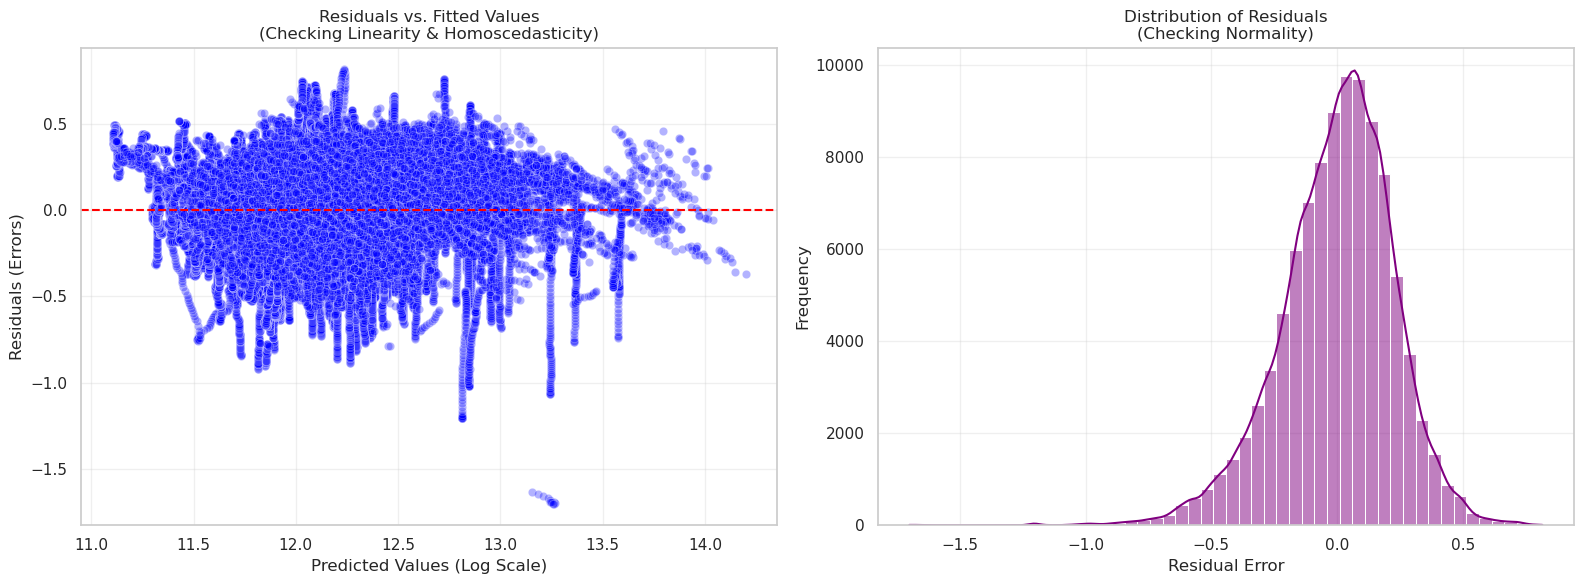

In [19]:
# ==========================================
# Gauss-Markov Diagnostics
# ==========================================
print("=" * 60)
print("CHECKING GAUSS-MARKOV ASSUMPTIONS")
print("=" * 60)

# Calculate predictions and residuals on the training set
y_train_pred_log = mlr_model.predict(X_train)
residuals = y_train_log - y_train_pred_log

# Assumption 2: Independence (Multicollinearity via VIF)
print("\n--- Variance Inflation Factor (VIF) ---")
print("Rule of thumb: VIF > 5-10 indicates problematic multicollinearity.\n")

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
display(vif_data)

# Visual Diagnostics Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Assumption 1 & 3: Linearity and Homoscedasticity (Residuals vs Fitted)
sns.scatterplot(x=y_train_pred_log, y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values\n(Checking Linearity & Homoscedasticity)')
axes[0].set_xlabel('Predicted Values (Log Scale)')
axes[0].set_ylabel('Residuals (Errors)')
axes[0].grid(True, alpha=0.3)

# Assumption 4: Normality of Residuals (Distribution Plot)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=50)
axes[1].set_title('Distribution of Residuals\n(Checking Normality)')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# Reproducibility Export & Handoff
# ==========================================
print("=" * 60)
print("EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS")
print("=" * 60)

# Save the trained model
model_save_path = os.path.join(dataset_path, "mlr_model_final.joblib")
joblib.dump(mlr_model, model_save_path)
print(f"Model saved successfully to: {model_save_path}")

# Create a results dictionary for reproducibility
results_summary = {
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": round(r2, 4),
        "rmse_test": round(rmse, 2),
        "mae_test": round(mae, 2),
        "mape_test_pct": round(mape, 2)
    },
    "model_parameters": {
        "intercept_log_scale": round(mlr_model.intercept_, 4),
        "features_used": list(X_train.columns)
    },
    "random_state": 42
}

# Save the results dictionary to JSON
summary_path = os.path.join(dataset_path, "mlr_baseline_summary.json")
with open(summary_path, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"Baseline results summary saved to: {summary_path}\n")

# 4. Display the final JSON output for confirmation
print("Final Exported Results:")
print(json.dumps(results_summary, indent=4))

EXPORTING MLR ARTIFACTS FOR SHAP ANALYSIS
Model saved successfully to: /home/ken/Documents/ml-course/FINAL PROJECT/Dataset/Model_Ready_Exports/mlr_model_final.joblib
Baseline results summary saved to: /home/ken/Documents/ml-course/FINAL PROJECT/Dataset/Model_Ready_Exports/mlr_baseline_summary.json

Final Exported Results:
{
    "model": "Multiple Linear Regression (Baseline)",
    "target_transformation": "log1p",
    "metrics": {
        "r2_test": 0.8271,
        "rmse_test": 74978.28,
        "mae_test": 50290.33,
        "mape_test_pct": 14.36
    },
    "model_parameters": {
        "intercept_log_scale": 12.0586,
        "features_used": [
            "rent",
            "for_sale",
            "days_pending",
            "price_cuts",
            "market_heat_index",
            "new_homeowner_affordability",
            "space_premium",
            "is_post_pandemic",
            "state_encoded"
        ]
    },
    "random_state": 42
}


# GPU-Accelerated XGBoost Regressor with RAPIDS and Optuna Hyperparameter Tuning

This notebook demonstrates using RAPIDS-native XGBoost for GPU-accelerated machine learning with automatic hyperparameter optimization using Optuna.

**Key Improvements:**
- **RAPIDS-Native Implementation**: Uses float32 enforcement and QuantileDMatrix for optimal GPU performance
- **Early Stopping**: Automatically finds optimal number of trees to prevent overfitting
- **GPU-Based MAPE Calculation**: Uses CuPy to avoid costly CPU transfers during tuning
- **Comprehensive Metrics**: Includes MAE, MAPE, and residual analysis for real estate predictions
- **Overfitting Prevention**: Uses min_child_weight and gamma to handle high-cardinality categorical features

In [34]:
import os

# DATASET_PATH = "xgb_dataset/"
# JSON_PATH = "xgb_json/"
# DB_PATH = "xgb_database/"
# SUMMARY_PATH = "xgb_summary/"

DATASET_PATH = "Dataset/Model_Ready_Exports/"
JSON_PATH = "XGB/xgb_json/"
DB_PATH = "XGB/xgb_database/"
SUMMARY_PATH = "XGB/xgb_summary/"

os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(SUMMARY_PATH, exist_ok=True)
os.makedirs(JSON_PATH , exist_ok=True)
os.makedirs(DB_PATH, exist_ok=True)

In [22]:
import cupy as cp
# GPU Monitoring Utility
import subprocess
import json

def check_gpu_status():
    """Check GPU memory usage and utilization using nvidia-smi"""
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.used,memory.total,utilization.gpu,utilization.memory',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        lines = result.stdout.strip().split('\n')
        print("=" * 60)
        print("                    GPU STATUS REPORT")
        print("=" * 60)
        for line in lines:
            parts = [p.strip() for p in line.split(',')]
            if len(parts) == 6:
                gpu_id, name, mem_used, mem_total, gpu_util, mem_util = parts
                print(f"GPU {gpu_id}: {name}")
                print(f"  Memory: {mem_used} MB / {mem_total} MB ({float(mem_used)/float(mem_total)*100:.1f}% used)")
                print(f"  GPU Utilization: {gpu_util}%")
                print(f"  Memory Utilization: {mem_util}%")
                print("-" * 60)
    else:
        print("Error: Could not query GPU status. Is nvidia-smi available?")
        print(result.stderr)

# Check GPU status
check_gpu_status()

# Also show GPU info via cupy
print("\n" + "=" * 60)
print("                 CUPL GPU INFORMATION")
print("=" * 60)
for i in range(cp.cuda.runtime.getDeviceCount()):
    device = cp.cuda.Device(i)
    with device:
        mem_info = device.mem_info
        device_props = cp.cuda.runtime.getDeviceProperties(i)
        device_name = device_props['name'].decode() if isinstance(device_props['name'], bytes) else device_props['name']
        print(f"GPU {i}: {device_name}")
        print(f"  Total Memory: {mem_info[1] / (1024**3):.2f} GB")
        print(f"  Free Memory: {mem_info[0] / (1024**3):.2f} GB")
        print(f"  Used Memory: {(mem_info[1] - mem_info[0]) / (1024**3):.2f} GB")
        print("-" * 60)
print("=" * 60)

                    GPU STATUS REPORT
GPU 0: NVIDIA GeForce GTX 1660 Ti
  Memory: 55 MB / 6144 MB (0.9% used)
  GPU Utilization: 26%
  Memory Utilization: 13%
------------------------------------------------------------

                 CUPL GPU INFORMATION
GPU 0: NVIDIA GeForce GTX 1660 Ti
  Total Memory: 5.61 GB
  Free Memory: 5.49 GB
  Used Memory: 0.12 GB
------------------------------------------------------------


In [23]:
# Cell 1: Production Data Ingestion & Type Enforcement

import cudf
import joblib
import cupy as cp
import numpy as np
import gc

print("=" * 60)
print("         PRODUCTION DATA LOADING")
print("=" * 60)

# ============================================================================
# 1. Load the Scaler
# ============================================================================
# #ASSUMPTION: Check if scaler was applied to features only or target as well
try:
    scaler = joblib.load(os.path.join(DATASET_PATH,'feature_scaler.pkl'))
    print(f"Scaler loaded: {type(scaler).__name__}")
except FileNotFoundError:
    print("Warning: feature_scaler.pkl not found. Proceeding without scaler.")
    scaler = None

# ============================================================================
# 2. Load Data directly into GPU DataFrames using cuDF
# ============================================================================
# #ASSUMPTION: Parquet files preserve dtypes and are highly compressed
# #ASSUMPTION: Using cuDF is significantly faster than pandas for GPU workflows
print("\nLoading parquet files into GPU memory...")
X_train_full = cudf.read_parquet(os.path.join(DATASET_PATH,'X_train.parquet'))
X_holdout = cudf.read_parquet(os.path.join(DATASET_PATH,'X_test.parquet'))  # This is the FINAL test set - untouched until evaluation
y_train_full = cudf.read_parquet(os.path.join(DATASET_PATH,'y_train.parquet'))
y_holdout = cudf.read_parquet(os.path.join(DATASET_PATH,'y_test.parquet'))  # This is the FINAL test set - untouched until evaluation

# Add this BEFORE splitting the data
# This creates a feature where 0 is the oldest record and len(df) is the newest
X_train_full['Time_Index'] = cp.arange(len(X_train_full))
train_end_idx = len(X_train_full)
X_holdout['Time_Index'] = cp.arange(train_end_idx, train_end_idx + len(X_holdout))
print("\u2713 Created Time_Index: Sequential proxy for the missing date field.")

# ============================================================================
# 3. CRITICAL: Float32 Enforcement (prevent 3x memory spike)
# ============================================================================
# #ASSUMPTION: Parquet defaults to float64. Implicit cast in QuantileDMatrix
# would use 3x memory temporarily (64 + 32 + metadata).
X_train_full = X_train_full.astype('float32')
X_holdout = X_holdout.astype('float32')
y_train_full = y_train_full.astype('float32')
y_holdout = y_holdout.astype('float32')

# ============================================================================
# 4. Ensure targets are 1D Series for XGBoost
# ============================================================================
# This handles both single-column and multi-column DataFrames
if hasattr(y_train_full, 'squeeze'):
    y_train_full = y_train_full.squeeze(axis=1)
if hasattr(y_holdout, 'squeeze'):
    y_holdout = y_holdout.squeeze(axis=1)

# ============================================================================
# #ASSUMPTION: If y values are z-scores (mean~0, std~1), target was already
# scaled. Running log1p on negative z-scores would produce NaNs and crash.
y_mean = float(y_train_full.values.mean())
y_std = float(y_train_full.values.std())
target_is_scaled = abs(y_mean) < 2 and 0.5 < y_std < 2

print(f"\nTarget statistics: mean={y_mean:.4f}, std={y_std:.4f}")
if target_is_scaled:
    print("WARNING: Target appears to be already scaled (z-scores).")
    print("  Skipping log-transformation. Will use np.expm1 for inverse.")
else:
    print("Target appears to be raw values. Will apply log1p transformation.")

# ============================================================================
# 6. GPU Memory Check (OOM Prevention)
# ============================================================================
train_mem_gb = X_train_full.memory_usage(deep=True).sum() / 1e9
holdout_mem_gb = X_holdout.memory_usage(deep=True).sum() / 1e9
total_gpu_mem_gb = cp.cuda.runtime.getDeviceProperties(0)['totalGlobalMem'] / 1e9

print(f"\nGPU Memory Usage:")
print(f"  X_train_full: {train_mem_gb:.2f} GB")
print(f"  X_holdout: {holdout_mem_gb:.2f} GB")
print(f"  Total GPU: {total_gpu_mem_gb:.2f} GB")
print(f"  Usage: {(train_mem_gb + holdout_mem_gb) / total_gpu_mem_gb * 100:.1f}%")

if (train_mem_gb + holdout_mem_gb) / total_gpu_mem_gb > 0.7:
    print("WARNING: Memory usage >70%. Running garbage collection...")
    gc.collect()

# ============================================================================
# 7. Data Validation
# ============================================================================
assert len(X_train_full) == len(y_train_full), f"Row mismatch: X_train_full={len(X_train_full)}, y_train_full={len(y_train_full)}"
assert len(X_holdout) == len(y_holdout), f"Row mismatch: X_holdout={len(X_holdout)}, y_holdout={len(y_holdout)}"
assert list(X_train_full.columns) == list(X_holdout.columns), "Column mismatch between train and holdout!"



print(f"\n\u2713 Data validation passed:")
print(f"  X_train_full: {X_train_full.shape}")
print(f"  y_train_full: {y_train_full.shape}")
print(f"  X_holdout: {X_holdout.shape}")
print(f"  y_holdout: {y_holdout.shape}")
print(f"  Columns: {list(X_train_full.columns)}")

# ============================================================================
# 8. Target Transformation (Log or Scaled)
# ============================================================================
# The actual y_train_log will be created after the train/val split in Cell 3
if target_is_scaled:
    y_holdout_log = y_holdout.values  # Already scaled
    print("\nUsing pre-scaled target values (no log transformation)")
else:
    y_holdout_log = cp.log1p(y_holdout.values)
    print("\nPrepared log1p transformation for holdout target (for final evaluation)")

print("\n" + "=" * 60)
print("PRODUCTION DATA LOADING COMPLETE")
print("=" * 60)
print("\nNOTE: X_holdout/y_holdout will NOT be used for Optuna tuning.")
print("      They are reserved for FINAL model evaluation only.")

         PRODUCTION DATA LOADING
Scaler loaded: StandardScaler

Loading parquet files into GPU memory...
✓ Created Time_Index: Sequential proxy for the missing date field.

Target statistics: mean=193366.0156, std=112217.0000
Target appears to be raw values. Will apply log1p transformation.

GPU Memory Usage:
  X_train_full: 0.00 GB
  X_holdout: 0.00 GB
  Total GPU: 6.03 GB
  Usage: 0.1%

✓ Data validation passed:
  X_train_full: (98532, 10)
  y_train_full: (98532,)
  X_holdout: (13923, 10)
  y_holdout: (13923,)
  Columns: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded', 'Time_Index']

Prepared log1p transformation for holdout target (for final evaluation)

PRODUCTION DATA LOADING COMPLETE

NOTE: X_holdout/y_holdout will NOT be used for Optuna tuning.
      They are reserved for FINAL model evaluation only.


In [24]:
# Cell 2: Check XGBoost and GPU Availability

import xgboost as xgb
import cupy as cp

print("=" * 60)
print("         XGBOOST & GPU AVAILABILITY CHECK")
print("=" * 60)

# Check XGBoost version
print(f"XGBoost Version: {xgb.__version__}")

# Check GPU availability
try:
    gpu_count = cp.cuda.runtime.getDeviceCount()
    print(f"CUDA GPU Count: {gpu_count}")

    # Test GPU memory allocation
    test_array = cp.zeros(10, dtype=cp.float32)
    print("\u2713 GPU memory allocation successful")

    # Check each GPU
    for i in range(gpu_count):
        device = cp.cuda.Device(i)
        with device:
            mem_info = device.mem_info
            print(f"  GPU {i}: {mem_info[1] / (1024**3):.2f} GB total memory")
except Exception as e:
    print(f"\u2717 GPU error: {e}")
    raise

print("\nXGBoost GPU Support:")
try:
    # Try to create a simple GPU-based estimator
    test_model = xgb.XGBRegressor(tree_method='gpu_hist', device='cuda')
    print("\u2713 XGBoost GPU support verified")
except Exception as e:
    print(f"\u2717 XGBoost GPU support error: {e}")
    print("  Falling back to CPU training")

print("=" * 60)

         XGBOOST & GPU AVAILABILITY CHECK
XGBoost Version: 3.2.0
CUDA GPU Count: 1
✓ GPU memory allocation successful
  GPU 0: 5.61 GB total memory

XGBoost GPU Support:
✓ XGBoost GPU support verified


In [25]:
# Cell 3: Sequential Time-Series Split (NO shuffling)
# In time-series data, random shuffling leaks future into the past!

import xgboost as xgb
import numpy as np
import cupy as cp

np.random.seed(42)
cp.random.seed(42)
import random
random.seed(42)


print("=" * 60)
print("         SEQUENTIAL TIME-SERIES SPLIT")
print("=" * 60)

# ============================================================================
# #ASSUMPTION: Data is ordered by time (Time_Index is sequential 0..N-1).
# Sequential split preserves temporal order: first 80% train, last 20% val.

print(f"Full training set size: {len(X_train_full)}")
print(f"Holdout set size (untouched): {len(X_holdout)}")

# Sort by Time_Index to guarantee chronological order
X_train_full = X_train_full.sort_values('Time_Index')
y_train_full = y_train_full.iloc[X_train_full.index]  # Align targets

# SEQUENTIAL SPLIT: First 80% for training, last 20% for validation
split_idx = int(len(X_train_full) * 0.8)
print(f"\nSequential split at index {split_idx}: {split_idx} train / {len(X_train_full) - split_idx} val")

X_train = X_train_full.iloc[:split_idx]
X_val = X_train_full.iloc[split_idx:]
y_train_full_split = y_train_full.iloc[:split_idx]
y_val_full = y_train_full.iloc[split_idx:]

print(f"  X_train: {X_train.shape} (rows 0:{split_idx})")
print(f"  X_val: {X_val.shape} (rows {split_idx}:{len(X_train_full)})")

# Apply log1p transformation to target (if not already scaled)
if target_is_scaled:
    y_train_log = y_train_full_split.values
    y_val_log = y_val_full.values
    print("\nUsing pre-scaled target values (no log transformation)")
else:
    y_train_log = cp.log1p(y_train_full_split.values)
    y_val_log = cp.log1p(y_val_full.values)
    print("\nApplied log1p transformation to target")
    print(f"  y_train_log range: {y_train_log.min():.2f} - {y_train_log.max():.2f}")

# ============================================================================
# CRITICAL: QuantileDMatrix Creation OUTSIDE Optuna Loop
# ============================================================================
# #ASSUMPTION: QuantileDMatrix pre-calculates histogram bins once. In a 50-trial
# Optuna study, this saves minutes of useless computation. Standard DMatrix
# recalculates histograms every time a tree is built.
# #ASSUMPTION: This is specifically optimized for 'hist' tree method (GPU default).

print("\n" + "=" * 60)
print("CREATING QUANTILEDMATRIX (GPU-Optimized)")
print("=" * 60)

print("Creating training QuantileDMatrix...")
train_qdm = xgb.QuantileDMatrix(X_train, label=y_train_log)

print("Creating validation QuantileDMatrix (with training reference)...")
# The 'ref' parameter is mandatory for consistent GPU histogram binning
val_qdm = xgb.QuantileDMatrix(X_val, label=y_val_log, ref=train_qdm)
print("\u2713 Validation QuantileDMatrix created and referenced")

print("\n#ASSUMPTION: QuantileDMatrix created once outside Optuna loop")
print("  - Pre-calculates histogram bins for 'hist' tree method")
print("  - Saves minutes in 50-trial study")
print("  - More memory-efficient than standard DMatrix")

# ============================================================================
# Store raw values for final MAPE calculation
# ============================================================================
y_train_raw = y_train_full_split.values if hasattr(y_train_full_split, 'values') else y_train_full_split
y_val_raw = y_val_full.values if hasattr(y_val_full, 'values') else y_val_full

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE - READY FOR OPTUNA TUNING")
print("=" * 60)
print("\nData Summary:")
print(f"  Training set (for Optuna): {len(X_train)} samples")
print(f"  Validation set (for Optuna): {len(X_val)} samples")
print(f"  Holdout set (FINAL evaluation only): {len(X_holdout)} samples")

import gc

# Store feature names first as a safeguard!
feature_names = X_train.columns.tolist()

training_size = len(X_train)
validation_size = len(X_val)
# NOW purge the raw data once and for all # DEL
del X_train, X_val, y_train_full_split, y_val_full
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

print("\u2713 Global raw data purged. QuantileDMatrices are ready for Optuna.")

         SEQUENTIAL TIME-SERIES SPLIT
Full training set size: 98532
Holdout set size (untouched): 13923

Sequential split at index 78825: 78825 train / 19707 val
  X_train: (78825, 10) (rows 0:78825)
  X_val: (19707, 10) (rows 78825:98532)

Applied log1p transformation to target
  y_train_log range: 10.76 - 13.96

CREATING QUANTILEDMATRIX (GPU-Optimized)
Creating training QuantileDMatrix...
Creating validation QuantileDMatrix (with training reference)...
✓ Validation QuantileDMatrix created and referenced

#ASSUMPTION: QuantileDMatrix created once outside Optuna loop
  - Pre-calculates histogram bins for 'hist' tree method
  - Saves minutes in 50-trial study
  - More memory-efficient than standard DMatrix

DATA PREPARATION COMPLETE - READY FOR OPTUNA TUNING

Data Summary:
  Training set (for Optuna): 78825 samples
  Validation set (for Optuna): 19707 samples
  Holdout set (FINAL evaluation only): 13923 samples
✓ Global raw data purged. QuantileDMatrices are ready for Optuna.


In [26]:
# Cell 4: Optuna Hyperparameter Tuning with GPU-Native XGBoost

import optuna
import json
import time
from datetime import datetime
import numpy as np
import cupy as cp

print("=" * 60)
print("         OPTUNA HYPERPARAMETER TUNING (XGBoost GPU)")
print("=" * 60)

# Set up Optuna study with SQLite backend for checkpoint/resume capability
STUDY_NAME = "xgboost_gpu_tuning"
STORAGE_URL = "sqlite:///"+DB_PATH+"tuning_progress.db"
N_TRIALS = 50

print(f"Study Name: {STUDY_NAME}")
print(f"Storage: {STORAGE_URL}")
print(f"Number of Trials: {N_TRIALS}")
print(f"Direction: Minimize MAPE (on ZHVI)")
print("=" * 60)
print()
print("Key XGBoost Features:")
print("  - GPU acceleration with tree_method='hist'")
print("  - Early stopping to find optimal n_estimators")
print("  - min_child_weight & gamma to prevent overfitting")
print("  - GPU-based MAPE calculation (avoids CPU transfer)")
print("  - Increased reg_alpha/reg_lambda ranges (0-50) for target-encoded features")
print("=" * 60)

sampler = optuna.samplers.TPESampler(seed=42, multivariate=True, group=True)
# Create or load study from database
study = optuna.create_study(
    direction="minimize",  # Minimize MAPE
    storage=STORAGE_URL,
    study_name=STUDY_NAME,
    load_if_exists=True,
    sampler=sampler
)

def objective(trial):
    """Objective function for Optuna hyperparameter optimization.

    Uses Time-Series Cross-Validation (Rolling Forecast Origin) with
    expanding windows to ensure hyperparameters are robust across
    multiple 'futures'. Calculates MAPE using CuPy to avoid CPU transfer.

    """
    import gc
    from sklearn.model_selection import TimeSeriesSplit

    # Define hyperparameter search space for XGBoost
    params = {
        # Tree method and device (MANDATORY for GPU)
        'tree_method': 'hist',  # GPU-optimized histogram method
        'device': 'cuda',            # Explicitly target GPU

        # Overfitting prevention (CRITICAL for high-cardinality zips)
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),  # CRITICAL
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),  # CRITICAL

        # Learning parameters
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),

        # Regularization (increased ranges for target-encoded features)
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 50),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 50),

        # Categorical support: DISABLED (states are already one-hot encoded)
        'enable_categorical': False,

        # Objective (try different options for outlier handling)
        'objective': trial.suggest_categorical('objective',
                                              ['reg:absoluteerror']),

        'random_state': 42,
        'seed': 42,
        'seed_per_iteration': False,  # Use same seed for all iterations

        'n_jobs': -1
    }

    # Use 3-fold Time-Series Cross-Validation (expanding window)
    tscv = TimeSeriesSplit(n_splits=3)
    fold_mapes = []

    # Iterate through rolling/expanding windows
    for fold, (train_index, val_index) in enumerate(tscv.split(X_train_full)):
        # Create temporary expanding window folds
        X_fold_train = X_train_full.iloc[train_index]
        X_fold_val = X_train_full.iloc[val_index]
        y_fold_train = y_train_full.iloc[train_index]
        y_fold_val = y_train_full.iloc[val_index]

        # CRITICAL: Recreate QuantileDMatrix for each fold
        # (since the data size changes with expanding windows)
        fold_train_qdm = xgb.QuantileDMatrix(
            X_fold_train,
            label=cp.log1p(y_fold_train.values)
        )
        fold_val_qdm = xgb.QuantileDMatrix(
            X_fold_val,
            label=cp.log1p(y_fold_val.values),
            ref=fold_train_qdm
        )

        # Train and evaluate on this fold
        model = xgb.train(
            params,
            fold_train_qdm,
            num_boost_round=1000,
            evals=[(fold_val_qdm, 'val')],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        # Predict and calculate MAPE on GPU
        y_pred_log = cp.asarray(model.predict(fold_val_qdm))
        y_pred_raw = cp.expm1(y_pred_log)
        y_actual_gpu = cp.asarray(y_fold_val.values)

        fold_mape = cp.mean(cp.abs((y_actual_gpu - y_pred_raw) / y_actual_gpu)) * 100
        fold_mapes.append(float(fold_mape))

        print(f"    Fold {fold+1} MAPE: {fold_mape:.2f}%")

        # CRITICAL: Clean up GPU memory after each fold (OOM prevention)
        del fold_train_qdm, fold_val_qdm, model, y_pred_log, y_pred_raw, y_actual_gpu
        del X_fold_train, X_fold_val, y_fold_train, y_fold_val
        gc.collect()
        cp.get_default_memory_pool().free_all_blocks()

    avg_mape = float(np.mean(fold_mapes))
    mape_std = float(np.std(fold_mapes))
    print(f"    Fold MAPEs: {[f'{m:.1f}%' for m in fold_mapes]}")
    print(f"    Average MAPE: {avg_mape:.2f}% +/- {mape_std:.2f}%")

    return avg_mape  # Minimize the average MAPE across all windows

# Custom callback to display progress
def show_progress(study, trial):
    if trial.number % 10 == 0 or trial.number == 0:
        print(f"\nTrial {trial.number}: MAPE = {trial.value:.2f}%")
        print(f"  Optimal trees: {trial.user_attrs.get('optimal_n_estimators', 'N/A')}")
        print(f"  Best MAPE so far: {study.best_value:.2f}% (Trial {study.best_trial.number})")
        print(f"  Best params: {study.best_params}")

# Run optimization
print(f"\nStarting optimization with {N_TRIALS} trials...")
start_time = time.time()

study.optimize(objective, n_trials=N_TRIALS, callbacks=[show_progress], show_progress_bar=True)

elapsed_time = time.time() - start_time

# Display optimization results
print("\n" + "=" * 60)
print("         OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"Total trials completed: {len(study.trials)}")
print(f"Time elapsed: {elapsed_time:.2f} seconds")
print(f"\nBest Trial: {study.best_trial.number}")
print(f"Best MAPE: {study.best_trial.value:.2f}%")
print(f"Optimal n_estimators: {study.best_trial.user_attrs.get('optimal_n_estimators', 'N/A')}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("=" * 60)

# Save optimization results to JSON
results = {
    'best_trial': study.best_trial.number,
    'best_value': study.best_trial.value,
    'best_params': study.best_params,
    'optimal_n_estimators': study.best_trial.user_attrs.get('optimal_n_estimators', None),
    'best_objective': study.best_params.get('objective', None),
    'n_trials': len(study.trials),
    'tuning_method': 'XGBoost GPU with Early Stopping',
    'metric': 'MAPE',
    'elapsed_time': elapsed_time,
    'timestamp': datetime.now().isoformat()
}

with open(os.path.join(JSON_PATH,'tuning_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to tuning_results.json")

/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(


         OPTUNA HYPERPARAMETER TUNING (XGBoost GPU)
Study Name: xgboost_gpu_tuning
Storage: sqlite:///XGB/xgb_database/tuning_progress.db
Number of Trials: 50
Direction: Minimize MAPE (on ZHVI)

Key XGBoost Features:
  - GPU acceleration with tree_method='hist'
  - Early stopping to find optimal n_estimators
  - min_child_weight & gamma to prevent overfitting
  - GPU-based MAPE calculation (avoids CPU transfer)
  - Increased reg_alpha/reg_lambda ranges (0-50) for target-encoded features


[I 2026-05-17 21:15:44,683] Using an existing study with name 'xgboost_gpu_tuning' instead of creating a new one.



Starting optimization with 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:15:45] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()


...

    Fold 1 MAPE: 9.69%


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:28:10] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()


    Fold 2 MAPE: 7.57%


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:28:18] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()
Best trial: 85. Best value: 8.88416: 100%|██████████| 50/50 [12:44<00:00, 15.29s/it]

    Fold 3 MAPE: 10.47%
    Fold MAPEs: ['9.7%', '7.6%', '10.5%']
    Average MAPE: 9.24% +/- 1.22%
[I 2026-05-17 21:28:28,941] Trial 99 finished with value: 9.243629137674967 and parameters: {'max_depth': 12, 'min_child_weight': 25, 'gamma': 2.8581659598348663, 'learning_rate': 0.008245493580529329, 'subsample': 0.952568294927654, 'colsample_bytree': 0.9871590030089131, 'reg_alpha': 6.943596890586954, 'reg_lambda': 6.04275023415087, 'objective': 'reg:absoluteerror'}. Best is trial 85 with value: 8.884160359700521.

         OPTIMIZATION COMPLETE
Total trials completed: 100
Time elapsed: 764.26 seconds

Best Trial: 85
Best MAPE: 8.88%
Optimal n_estimators: N/A

Best Hyperparameters:
  max_depth: 7
  min_child_weight: 10
  gamma: 0.4758285586585349
  learning_rate: 0.08681492988569786
  subsample: 0.9600397414075735
  colsample_bytree: 0.9088144821461728
  reg_alpha: 2.8768097406044806
  reg_lambda: 16.307843143886572
  objective: reg:absoluteerror

Results saved to tuning_results.json


         OPTIMIZATION VISUALIZATION


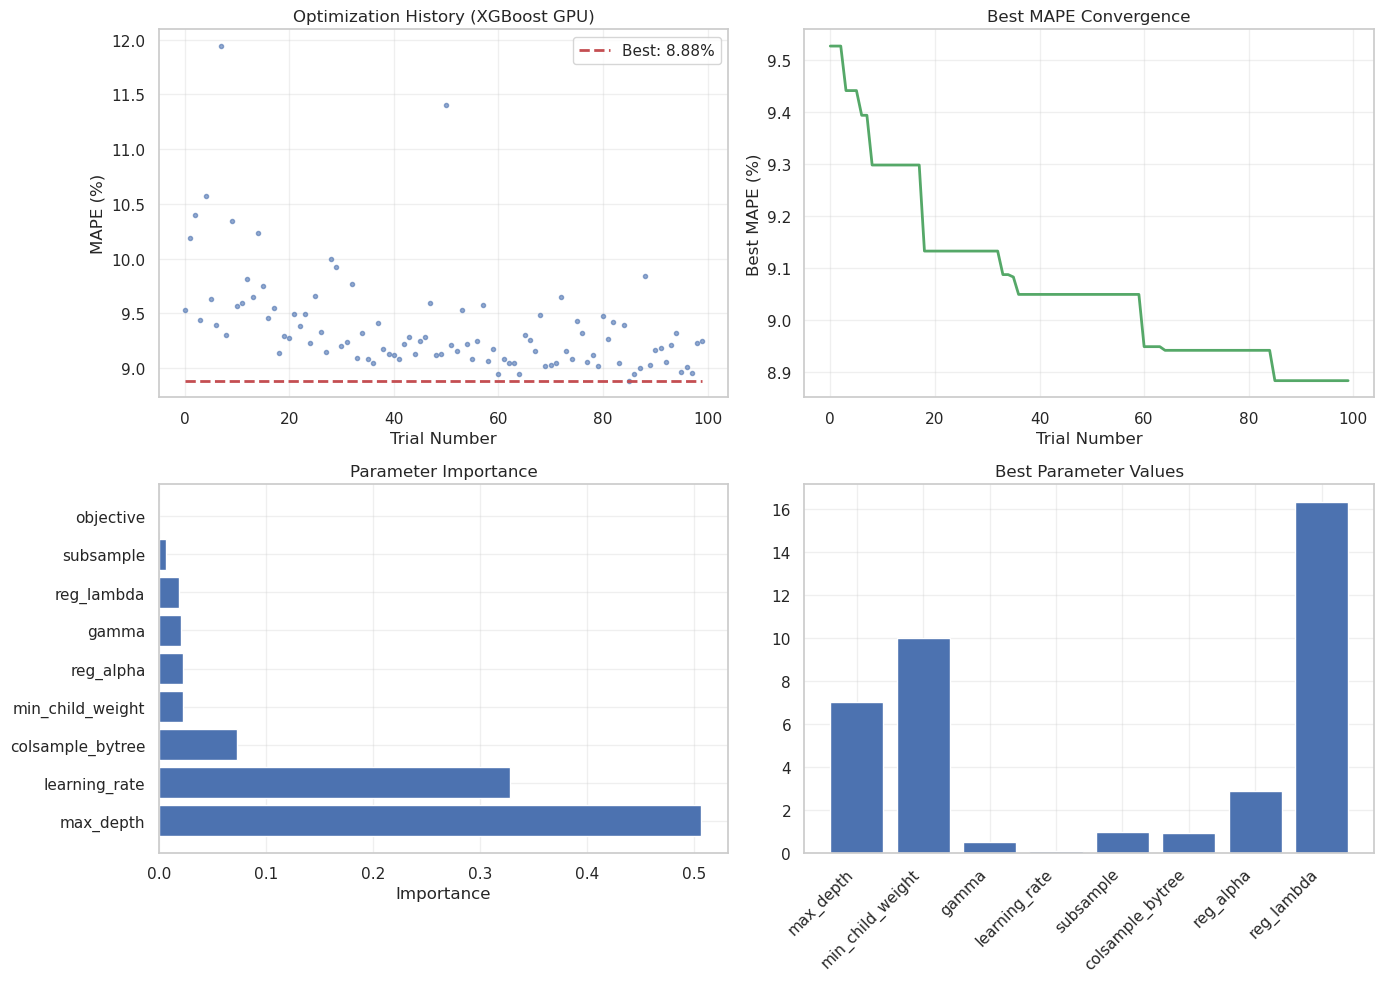


Visualization complete.


In [27]:
# Cell 5: Optimization Visualization with Residual Analysis
import optuna
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

print("=" * 60)
print("         OPTIMIZATION VISUALIZATION")
print("=" * 60)

# Plot optimization history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
STUDY_NAME = "xgboost_gpu_tuning"
STORAGE_URL = "sqlite:///"+DB_PATH+"tuning_progress.db"
study = optuna.load_study(
    storage=STORAGE_URL,
    study_name=STUDY_NAME,
)

# 1. Optimization history (MAPE values)
axes[0, 0].plot([t.value for t in study.trials], 'b.', alpha=0.6)
axes[0, 0].plot([study.best_value] * len(study.trials), 'r--', linewidth=2, label=f'Best: {study.best_value:.2f}%')
axes[0, 0].set_xlabel('Trial Number')
axes[0, 0].set_ylabel('MAPE (%)')
axes[0, 0].set_title('Optimization History (XGBoost GPU)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Best value over trials (cumulative best)
best_values = []
current_best = float('inf')

for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None:
        if t.value < current_best:
            current_best = t.value
        best_values.append(current_best)
    elif len(best_values) > 0:
        best_values.append(current_best)
    else:
        best_values.append(float('inf'))

axes[0, 1].plot(best_values, 'g-', linewidth=2)
axes[0, 1].set_xlabel('Trial Number')
axes[0, 1].set_ylabel('Best MAPE (%)')
axes[0, 1].set_title('Best MAPE Convergence')
axes[0, 1].grid(True, alpha=0.3)

# 3. Parameter importance
try:
    if len(study.trials) >= 10:
        param_importance = optuna.importance.get_param_importances(study)
        params = list(param_importance.keys())
        importances = list(param_importance.values())
        axes[1, 0].barh(params, importances)
        axes[1, 0].set_xlabel('Importance')
        axes[1, 0].set_title('Parameter Importance')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        raise ValueError(f'Not enough trials ({len(study.trials)})')
except Exception as e:
    axes[1, 0].text(0.5, 0.7, f'Importance not available\n({str(e)})',
                    ha='center', va='center', transform=axes[1, 0].transAxes,
                    fontsize=10, style='italic')
    axes[1, 0].set_title('Parameter Value Distribution')

# 4. Best parameter values
best_params = study.best_params
numeric_params = {k: v for k, v in best_params.items() if isinstance(v, (int, float))}
if numeric_params:
    axes[1, 1].bar(range(len(numeric_params)), list(numeric_params.values()))
    axes[1, 1].set_xticks(range(len(numeric_params)))
    axes[1, 1].set_xticklabels(list(numeric_params.keys()), rotation=45, ha='right')
    axes[1, 1].set_title('Best Parameter Values')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete.")

In [28]:
import cupy as cp


In [29]:
# Cell 6: Train Final Model with Best Hyperparameters
import time
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import gc

# 1. Prepare Final Training Data
train_full_qdm = xgb.QuantileDMatrix(X_train_full, label=cp.log1p(y_train_full.values))

print("=" * 60)
print("         FINAL MODEL TRAINING")
print("=" * 60)


# Use best hyperparameters from Optuna
best_params = study.best_params
print(f"\nUsing best hyperparameters from tuning:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Add GPU parameters and best n_estimators
best_params['seed'] = 42
best_params['seed_per_iteration'] = False
best_params['random_state'] = 42

best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['n_estimators'] = study.best_trial.user_attrs.get('optimal_n_estimators', 100)
best_params['enable_categorical'] = False

# 3. Final Train using num_boost_round from Optuna's best trial
best_iteration = study.best_trial.user_attrs.get('best_iteration', 1000)

print(f"\nFinal model will use {best_params['n_estimators']} trees (from early stopping)")

# Initialize XGBRegressor with best hyperparameters
xgb_model = xgb.XGBRegressor(**best_params)

# Train the model on GPU with early stopping
print(f"Training final Booster with {best_iteration} rounds...")
start_time = time.time()
final_model = xgb.train(
    best_params,
    train_full_qdm,
    num_boost_round=best_iteration
)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.4f} seconds")

# 4. Predict on Holdout
holdout_qdm = xgb.QuantileDMatrix(X_holdout, label=cp.log1p(y_holdout.values), ref=train_full_qdm)

# Make predictions on HOLDOUT set (final evaluation)
print("\nMaking predictions on holdout set (FINAL evaluation)...")
start_time = time.time()
y_pred_log = final_model.predict(holdout_qdm)
predict_time = time.time() - start_time
print(f"Prediction completed in {predict_time:.4f} seconds")

y_pred = np.expm1(y_pred_log)                  # predictions
y_holdout_raw = cp.asnumpy(y_holdout.values).flatten()  # actual values


# 5. Clean up Training Data and Optuna study before metric calculation
del X_train_full, train_full_qdm, holdout_qdm
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

total_trialsF = len(study.trials)
best_trialF = study.best_trial.number
best_MAPEF = study.best_trial.value
optimal_n_estF = study.best_trial.user_attrs.get('optimal_n_estimators', 'N/A')

best_objF = study.best_params.get('objective', 'N/A')
study_best_itemsF = study.best_params.items()
min_child_weightF = study.best_params.get('min_child_weight', 'N/A')
gammaF = study.best_params.get('gamma', 'N/A')

# 5b. Clean up Optuna study and database connection
try:
    if 'study' in globals():
        if hasattr(study, '_storage') and hasattr(study._storage, 'engine'):
            study._storage.engine.dispose()
        del study
        print("\u2713 Optuna study cache cleared (DB connection disposed)")
except Exception as e:
    print(f"Warning: Could not fully clean up study: {e}")

gc.collect()
cp.get_default_memory_pool().free_all_blocks()
print("\u2713 GPU memory fully freed after final training")

# Evaluate model performance with comprehensive metrics
print("Calculating final metrics on CPU...")
r2_test = r2_score(y_holdout_raw, y_pred)
mse_test = mean_squared_error(y_holdout_raw, y_pred)
mae_test = mean_absolute_error(y_holdout_raw, y_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE - interpretable as percentage error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_test = mean_absolute_percentage_error(y_holdout_raw, y_pred)

print(f"\n" + "=" * 60)
print("         FINAL MODEL EVALUATION (on Holdout Set)")
print("=" * 60)
print(f"Holdout R\u00b2 score: {r2_test:.4f}")
print(f"Holdout MSE: {mse_test:.4f}")
print(f"Holdout RMSE: {np.sqrt(mse_test):.4f}")
print(f"Holdout MAE: {mae_test:.4f}")
print(f"Holdout MAPE: {mape_test:.2f}% (average percentage error)")
print("=" * 60)
print()
print("Metric Interpretations:")
print(f"  - MAE = {mae_test:.4f}: On average, predictions are off by {mae_test:.4f} units")
print(f"  - MAPE = {mape_test:.2f}%: On average, predictions are off by {mape_test:.2f}%")
print(f"  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k")

         FINAL MODEL TRAINING

Using best hyperparameters from tuning:
  max_depth: 7
  min_child_weight: 10
  gamma: 0.4758285586585349
  learning_rate: 0.08681492988569786
  subsample: 0.9600397414075735
  colsample_bytree: 0.9088144821461728
  reg_alpha: 2.8768097406044806
  reg_lambda: 16.307843143886572
  objective: reg:absoluteerror

Final model will use 100 trees (from early stopping)
Training final Booster with 1000 rounds...


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:28:30] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/learner.cc:782: 
Parameters: { "enable_categorical", "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed in 4.5244 seconds

Making predictions on holdout set (FINAL evaluation)...
Prediction completed in 0.0269 seconds
✓ Optuna study cache cleared (DB connection disposed)
✓ GPU memory fully freed after final training
Calculating final metrics on CPU...

         FINAL MODEL EVALUATION (on Holdout Set)
Holdout R² score: 0.9413
Holdout MSE: 1908242304.0000
Holdout RMSE: 43683.4328
Holdout MAE: 25960.4961
Holdout MAPE: 7.34% (average percentage error)

Metric Interpretations:
  - MAE = 25960.4961: On average, predictions are off by 25960.4961 units
  - MAPE = 7.34%: On average, predictions are off by 7.34%
  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k


In [30]:
# Cell 7: Save the Trained Model (Native XGBoost Format)
import os

print("=" * 60)
print("         MODEL SAVE (Native Booster Format)")
print("=" * 60)

model_path = os.path.join(JSON_PATH,"xgboost_booster.json")

# SAVE using the Booster object from Cell 6
print("Saving model to native XGBoost JSON format...")
# Use 'final_model' (the Booster), not 'xgb_model' (the empty sklearn wrapper)
final_model.save_model(model_path)

file_size = os.path.getsize(model_path)
print(f"Model saved to: {model_path} ({file_size/1024:.2f} KB)")

# Save best parameters separately
params_path = os.path.join(JSON_PATH,"best_params.json")
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=2)
print(f"Best parameters saved to: {params_path}")

print("\n" + "=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

         MODEL SAVE (Native Booster Format)
Saving model to native XGBoost JSON format...
Model saved to: XGB/xgb_json/xgboost_booster.json (9549.70 KB)
Best parameters saved to: XGB/xgb_json/best_params.json

MODEL SAVED SUCCESSFULLY


In [35]:
# Cell 7b: Load Model and Make Predictions (STANDALONE — no training required)
# =====================================================================
# This cell is FULLY INDEPENDENT. It does NOT require any previous cell
# to have been run. It loads the saved model and data from disk.
# Any user with these files can run just this cell to get predictions:
#   - xgb_json/xgboost_booster.json
#   - xgb_json/best_params.json
#   - xgb_dataset/X_test.parquet
#   - xgb_dataset/y_test.parquet
#   - xgb_dataset/feature_scaler.pkl
# =====================================================================
import os
import json
import warnings
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print("=" * 60)
print("         LOAD MODEL & PREDICT (Standalone)")
print("=" * 60)

# ── 1. Load the trained model ──
model_path = os.path.join(JSON_PATH, "xgboost_booster.json")
print(f"Loading trained model from: {model_path}")

import xgboost as xgb
final_model = xgb.XGBRegressor()
final_model.load_model(model_path)
print("✓ Model loaded successfully!")

# ── 2. Load best parameters (for reference) ──
params_path = os.path.join(JSON_PATH, "best_params.json")
if os.path.exists(params_path):
    with open(params_path, 'r') as f:
        best_params = json.load(f)
    print(f"Best parameters loaded from: {params_path}")
    print(f"  Best MAPE: {best_params.get('best_value', 'N/A')}%")
    print(f"  Optimal trees: {best_params.get('optimal_n_estimators', best_params.get('n_estimators', 'N/A'))}")
else:
    print("Note: best_params.json not found (proceeding with model only)")

# ── 3. Load the holdout data ──
print("\nLoading holdout data from parquet files...")
import cudf
import cupy as cp

X_holdout = cudf.read_parquet(os.path.join(DATASET_PATH, 'X_test.parquet'))
y_holdout = cudf.read_parquet(os.path.join(DATASET_PATH, 'y_test.parquet'))

# Ensure float32 for GPU efficiency
X_holdout = X_holdout.astype('float32')
y_holdout = y_holdout.astype('float32')

# Ensure targets are 1D
if hasattr(y_holdout, 'squeeze'):
    y_holdout = y_holdout.squeeze(axis=1)

# Add Time_Index feature if not present (needed for QuantileDMatrix compatibility)
if 'Time_Index' not in X_holdout.columns:
    metadata_path = os.path.join(JSON_PATH, 'metadata.json')
    # with open(metadata_path) as f:
    #     metadata = json.load(f)
    # train_end_idx = metadata['train_end_idx']
    X_holdout['Time_Index'] = cp.arange(train_end_idx, train_end_idx + len(X_holdout))


print(f"  X_holdout: {X_holdout.shape}")
print(f"  y_holdout: {y_holdout.shape}")

# ── 4. Check target scaling ──
y_mean = float(y_holdout.values.mean())
y_std = float(y_holdout.values.std())
target_is_scaled = abs(y_mean) < 2 and 0.5 < y_std < 2

print(f"\nTarget statistics: mean={y_mean:.4f}, std={y_std:.4f}")
if target_is_scaled:
    print("Target appears to be already scaled (z-scores).")
    y_holdout_log = y_holdout.values
else:
    print("Target is raw values. Applying log1p transformation.")
    y_holdout_log = cp.log1p(y_holdout.values)

# ── 5. Make predictions ──
print("\nMaking predictions on holdout set...")
y_pred_log = final_model.predict(X_holdout)
y_pred = np.expm1(y_pred_log)
y_holdout_raw = cp.asnumpy(y_holdout.values) if hasattr(y_holdout.values, 'get') else np.array(y_holdout.values)

# ── 6. Evaluate metrics ──
print("Calculating evaluation metrics...")

r2_test = r2_score(y_holdout_raw, y_pred)
mse_test = mean_squared_error(y_holdout_raw, y_pred)
mae_test = mean_absolute_error(y_holdout_raw, y_pred)

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate MAPE — interpretable as percentage error."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_test = mean_absolute_percentage_error(y_holdout_raw, y_pred)

print(f"\n" + "=" * 60)
print("         FINAL MODEL EVALUATION (on Holdout Set)")
print("=" * 60)
print(f"Holdout R² score: {r2_test:.4f}")
print(f"Holdout MSE: {mse_test:.4f}")
print(f"Holdout RMSE: {np.sqrt(mse_test):.4f}")
print(f"Holdout MAE: {mae_test:.4f}")
print(f"Holdout MAPE: {mape_test:.2f}% (average percentage error)")
print("=" * 60)
print()
print("Metric Interpretations:")
print(f"  - MAE = {mae_test:.4f}: On average, predictions are off by {mae_test:.4f} units")
print(f"  - MAPE = {mape_test:.2f}%: On average, predictions are off by {mape_test:.2f}%")
print(f"  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k")

         LOAD MODEL & PREDICT (Standalone)
Loading trained model from: XGB/xgb_json/xgboost_booster.json
✓ Model loaded successfully!
Best parameters loaded from: XGB/xgb_json/best_params.json
  Best MAPE: N/A%
  Optimal trees: 100

Loading holdout data from parquet files...
  X_holdout: (13923, 10)
  y_holdout: (13923,)

Target statistics: mean=342787.5625, std=180336.4688
Target is raw values. Applying log1p transformation.

Making predictions on holdout set...
Calculating evaluation metrics...

         FINAL MODEL EVALUATION (on Holdout Set)
Holdout R² score: 0.9413
Holdout MSE: 1908224384.0000
Holdout RMSE: 43683.2277
Holdout MAE: 25960.3965
Holdout MAPE: 7.34% (average percentage error)

Metric Interpretations:
  - MAE = 25960.3965: On average, predictions are off by 25960.3965 units
  - MAPE = 7.34%: On average, predictions are off by 7.34%
  - For real estate: If price is $500k and MAPE is 5%, avg error = $25k


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [21:33:49] WARNING: /home/task_177741004711274/croot/xgboost-split_1777410104453/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cpu, while the input data is on: cuda:0.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


         FEATURE IMPORTANCE ANALYSIS (Gain-Based)


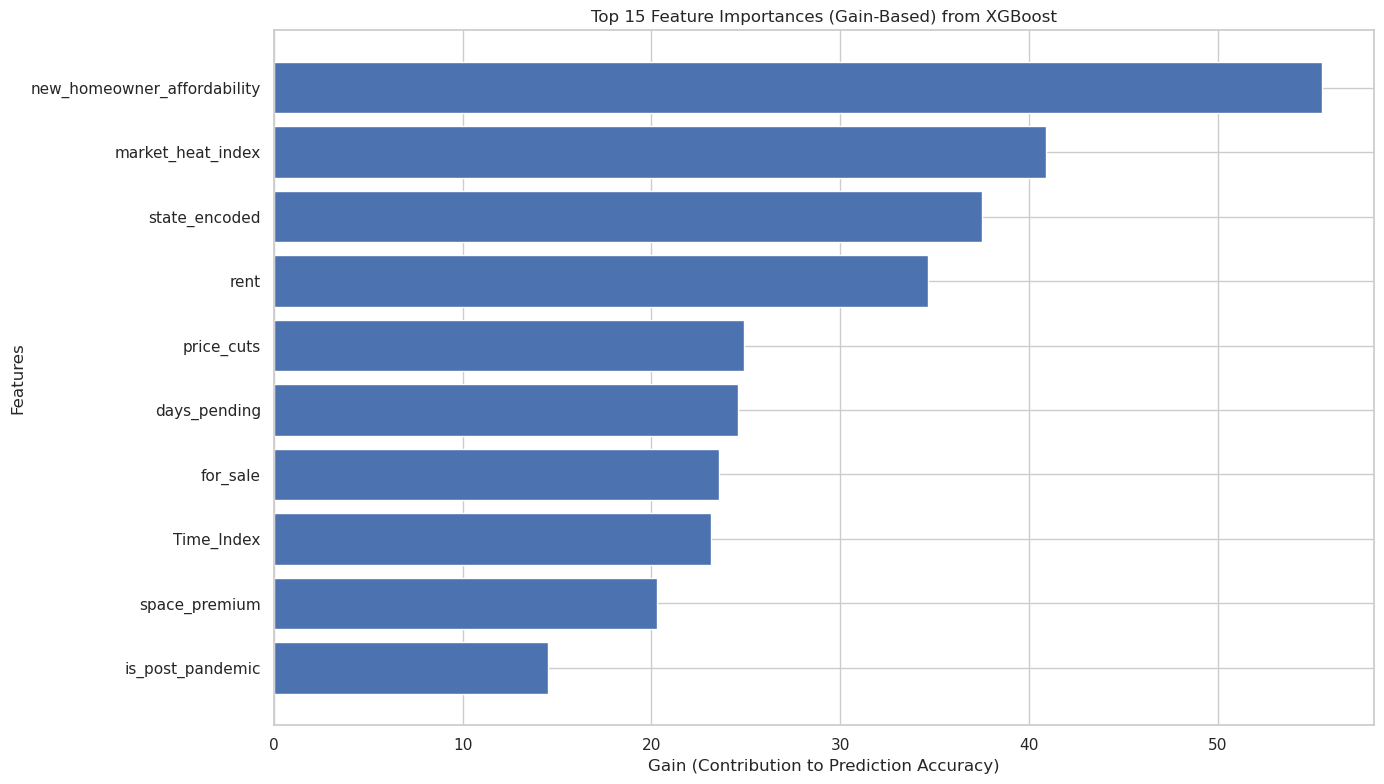


Top 10 Most Important Features (by Gain):
  new_homeowner_affordability: 55.5044
  market_heat_index: 40.8879
  state_encoded: 37.4993
  rent: 34.6750
  price_cuts: 24.8851
  days_pending: 24.5897
  for_sale: 23.5952
  Time_Index: 23.1754
  space_premium: 20.2919
  is_post_pandemic: 14.5352

#ASSUMPTION: Gain shows actual contribution to prediction accuracy
  - High gain = feature significantly improves predictions
  - More meaningful than 'weight' (split frequency) for real estate


In [36]:
# Cell 8: Feature Importance Analysis (Gain-Based)
import matplotlib.pyplot as plt

print("=" * 60)
print("         FEATURE IMPORTANCE ANALYSIS (Gain-Based)")
print("=" * 60)

# Get the underlying booster (works for both Booster and XGBRegressor)
if hasattr(final_model, 'get_booster'):
    booster = final_model.get_booster()
else:
    booster = final_model
importance = booster.get_score(importance_type='gain')


# Convert to arrays for plotting
feature_names_xgb = list(importance.keys())
feature_importances = list(importance.values())

# Sort by importance
indices = np.argsort(feature_importances)[::-1]
feature_names_sorted = [feature_names_xgb[i] for i in indices]
feature_importances_sorted = [feature_importances[i] for i in indices]

# Plot feature importances
plt.figure(figsize=(14, 8))
top_n = min(15, len(feature_importances_sorted))

plt.barh(range(top_n), feature_importances_sorted[:top_n][::-1])
plt.yticks(range(top_n), feature_names_sorted[:top_n][::-1])
plt.xlabel('Gain (Contribution to Prediction Accuracy)')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances (Gain-Based) from XGBoost')
plt.tight_layout()
plt.show()

# Print top 10 most important features
print(f"\nTop 10 Most Important Features (by Gain):")
for i in range(min(10, len(feature_importances_sorted))):
    print(f"  {feature_names_sorted[i]}: {feature_importances_sorted[i]:.4f}")

print("\n#ASSUMPTION: Gain shows actual contribution to prediction accuracy")
print("  - High gain = feature significantly improves predictions")
print("  - More meaningful than 'weight' (split frequency) for real estate")

         FINAL PROJECT SUMMARY REPORT


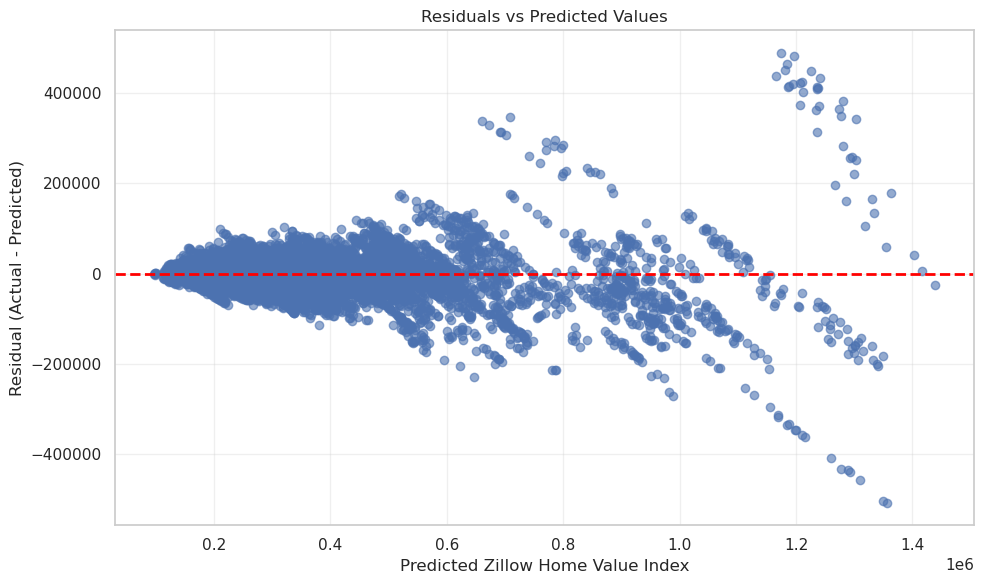


GPU-Accelerated XGBoost Regressor - Final Project Report

Generated: 2026-05-17 21:33:58

1. DATA SUMMARY
   - Total samples: 92,748
   - Features: 10
   - Training samples: 78825
   - Validation samples (for Optuna): 19707
   - Holdout samples (FINAL evaluation): 13,923
   - Target transformation: log1p (stabilizes variance)

2. GPU OPTIMIZATION
   - Data type: float32 (50% memory reduction)
   - Tree method: hist (GPU-optimized histogram)
   - QuantileDMatrix: Pre-calculated bins (saves minutes)
   - MAPE calculation: GPU-based (avoids CPU transfer)

3. HYPERPARAMETER TUNING (Optuna with Early Stopping)
   - Total trials: 100
   - Best trial: 85
   - Best MAPE: 8.88%
   - Optimal n_estimators: None
   - Best objective: reg:absoluteerror
   - Best hyperparameters:
     - max_depth: 7
     - min_child_weight: 10
     - gamma: 0.4758285586585349
     - learning_rate: 0.08681492988569786
     - subsample: 0.9600397414075735
     - colsample_bytree: 0.9088144821461728
     - reg_alpha: 2

In [37]:
# Cell 9: Generate Summary Report with Future Work
from datetime import datetime
import matplotlib.pyplot as plt
import json

print("=" * 60)
print("         FINAL PROJECT SUMMARY REPORT")
print("=" * 60)

# Load tuning results from JSON (works with or without training pipeline)
tuning_results_path = os.path.join(JSON_PATH, 'tuning_results.json')
if os.path.exists(tuning_results_path):
    with open(tuning_results_path, 'r') as f:
        tuning_results = json.load(f)
    total_trialsF = tuning_results.get('n_trials', 'N/A')
    best_trialF = tuning_results.get('best_trial', 'N/A')
    best_MAPEF = tuning_results.get('best_value', 'N/A')
    optimal_n_estF = tuning_results.get('optimal_n_estimators', 'N/A')
    best_objF = tuning_results.get('best_objective', 'N/A')
    tuning_params = tuning_results.get('best_params', {})
    study_best_itemsF = list(tuning_params.items())
    min_child_weightF = tuning_params.get('min_child_weight', 'N/A')
    gammaF = tuning_params.get('gamma', 'N/A')
else:
    # Fallback: try loading best_params.json directly
    params_fallback_path = os.path.join(JSON_PATH, 'best_params.json')
    if os.path.exists(params_fallback_path):
        with open(params_fallback_path, 'r') as f:
            tuning_params = json.load(f)
        study_best_itemsF = list(tuning_params.items())
        min_child_weightF = tuning_params.get('min_child_weight', 'N/A')
        gammaF = tuning_params.get('gamma', 'N/A')
    else:
        study_best_itemsF = []
        min_child_weightF = 'N/A'
        gammaF = 'N/A'
    total_trialsF = best_trialF = best_MAPEF = optimal_n_estF = best_objF = 'N/A'

# Store predictions for residual analysis
residuals = y_holdout_raw - y_pred
# Create residual plot for the report
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuals, alpha=0.6)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Zillow Home Value Index')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Predicted Values')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_PATH,'residual_plot.png'), dpi=150)
plt.show()

report = f"""
GPU-Accelerated XGBoost Regressor - Final Project Report
============================================================

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

1. DATA SUMMARY
   - Total samples: {training_size + len(X_holdout):,}
   - Features: {X_holdout.shape[1]}
   - Training samples: {training_size}
   - Validation samples (for Optuna): {validation_size}
   - Holdout samples (FINAL evaluation): {len(X_holdout):,}
   - Target transformation: log1p (stabilizes variance)

2. GPU OPTIMIZATION
   - Data type: float32 (50% memory reduction)
   - Tree method: hist (GPU-optimized histogram)
   - QuantileDMatrix: Pre-calculated bins (saves minutes)
   - MAPE calculation: GPU-based (avoids CPU transfer)

3. HYPERPARAMETER TUNING (Optuna with Early Stopping)
   - Total trials: {total_trialsF}
   - Best trial: {best_trialF}
   - Best MAPE: {best_MAPEF:.2f}%
   - Optimal n_estimators: {optimal_n_estF}
   - Best objective: {best_objF}
   - Best hyperparameters:
"""

for key, value in study_best_itemsF:
    report += f"     - {key}: {value}\n"

report += f"""
4. FINAL MODEL PERFORMANCE (on Holdout Set)
   - Holdout R\u00b2: {r2_test:.4f}
   - Holdout MSE: {mse_test:.4f}
   - Holdout RMSE: {np.sqrt(mse_test):.4f}
   - Holdout MAE: {mae_test:.4f} (interpretable in actual units)
   - Holdout MAPE: {mape_test:.2f}% (average percentage error)

5. METRIC INTERPRETATIONS
   - MAE: On average, predictions are off by {mae_test:.4f} units
   - MAPE: On average, predictions are off by {mape_test:.2f}%
   - For real estate: If price is $500k and MAPE is 5%, avg error = $25k

6. OVERFITTING PREVENTION
   - min_child_weight: {min_child_weightF} (prevents single-zip leaves)
   - gamma: {gammaF} (requires minimum loss reduction)
   - Early stopping: 50 rounds (automatically finds optimal trees)

7. TOP 5 MOST IMPORTANT FEATURES (Gain-Based)
"""

for i in range(min(5, len(feature_importances_sorted))):
    report += f"   - {feature_names_sorted[i]}: {feature_importances_sorted[i]:.4f}\n"

report += f"""
8. FILES GENERATED
   - Model: {model_path} (native XGBoost JSON)
   - Parameters: {params_path}
   - Tuning results: tuning_results.json
   - Residual plot: residual_plot.png
   - Optuna database: tuning_progress.db

9. FUTURE WORK: Multi-GPU Scaling with Dask
   For production deployment at Zillow scale (millions of properties),
   this single-GPU implementation would be extended using Dask:

   ```python
   import dask_cuml
   from dask_xgboost import XGBRegressor

   # Distribute across GPU cluster
   client = Client(n_workers=4, threads_per_worker=1, processes=False)

   # Dask-aware XGBoost
   model = XGBRegressor(tree_method='hist', device='cuda')
   model.fit(dask_X_train, dask_y_train)
   ```

   Benefits:
   - Horizontal scaling across multiple GPUs
   - Handle datasets larger than single GPU memory
   - Faster hyperparameter tuning with distributed Optuna

============================================================
"""

print(report)

# Save report to file
with open(os.path.join(SUMMARY_PATH,'project_report.txt'), 'w') as f:
    f.write(report)

print("Report saved to: project_report.txt")
print("=" * 60)

In [38]:
# from google.colab import drive
# drive.mount('/content/drive')

base_path = ''
scaler_path = base_path + 'Dataset/Model_Ready_Exports/feature_scaler.pkl'
x_test_path = base_path + 'Dataset/Model_Ready_Exports/X_test.parquet'
y_test_path = base_path + 'Dataset/Model_Ready_Exports/y_test.parquet'
xgb_model_path = base_path + 'XGB/xgb_json/xgboost_booster.json' #Modified to new path json

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import xgboost as xgb
from sklearn.linear_model import LinearRegression

In [41]:
# load data and scaler
scaler = joblib.load(scaler_path)
X_test = pd.read_parquet(x_test_path)
y_test = pd.read_parquet(y_test_path).squeeze()

In [42]:
# reconstruct MLR model (coefficients from Vince’s notebook)
mlr = LinearRegression()
mlr.intercept_ = 12.0586

mlr.coef_ = np.array([
    0.205389,   # rent
    0.006595,   # for_sale
   -0.043229,   # days_pending
    0.027659,   # price_cuts
    0.088828,   # market_heat_index
    0.022907,   # new_homeowner_affordability
   -0.076276,   # space_premium
    0.025667,   # is_post_pandemic
    0.084938    # state_encoded
])

In [43]:
# load XGBoost booster
xgb_booster = xgb.Booster()
xgb_booster.load_model(xgb_model_path)
dtest = xgb.DMatrix(X_test.values, feature_names=X_test.columns.tolist())

In [44]:
# sample for SHAP (2000 rows)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
dtest_sample = xgb.DMatrix(X_sample.values, feature_names=X_test.columns.tolist())

In [45]:
# MLR SHAP (LinearExplainer)
print("Running LinearExplainer...")
explainer_linear = shap.LinearExplainer(mlr, X_test, feature_perturbation="interventional")
shap_values_linear = explainer_linear.shap_values(X_sample)

# Bar plot
plt.figure()
shap.summary_plot(shap_values_linear, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_mlr_bar.png', dpi=300)
plt.close()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_linear, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_mlr_beeswarm.png', dpi=300)
plt.close()

Running LinearExplainer...


/opt/anaconda/envs/rapids-26.04/lib/python3.12/site-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/tmp/ipykernel_329288/3660356659.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_linear, X_sample, plot_type="bar", show=False)
/tmp/ipykernel_329288/3660356659.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_linear, X_sample, show=False)


In [46]:
# Check what features the XGBoost model expects
print("Booster feature names:", xgb_booster.feature_names)
print("X_test columns:", X_test.columns.tolist())
print("Booster num features:", getattr(xgb_booster, 'num_features', 'unknown'))

Booster feature names: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded', 'Time_Index']
X_test columns: ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index', 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic', 'state_encoded']
Booster num features: <bound method Booster.num_features of <xgboost.core.Booster object at 0x7ff89c29f320>>


In [47]:
start_idx = int(112455 - len(X_test))   # should be 98532
X_test['Time_Index'] = np.arange(start_idx, start_idx + len(X_test))

# Ensure the columns are in the exact order the booster expects
expected_cols = ['rent', 'for_sale', 'days_pending', 'price_cuts', 'market_heat_index',
                 'new_homeowner_affordability', 'space_premium', 'is_post_pandemic',
                 'state_encoded', 'Time_Index']
X_test = X_test[expected_cols]

# Recreate the DMatrix and the sample
dtest = xgb.DMatrix(X_test.values, feature_names=expected_cols)
X_sample = X_test.iloc[sample_idx]
dtest_sample = xgb.DMatrix(X_sample.values, feature_names=expected_cols)

print("Time_Index added. X_test now has", X_test.shape[1], "features.")

Time_Index added. X_test now has 10 features.


In [48]:
# XGBoost SHAP (TreeExplainer)
print("Running TreeExplainer...")
explainer_tree = shap.TreeExplainer(xgb_booster)
shap_values_tree = explainer_tree.shap_values(dtest_sample)

# Bar plot
plt.figure()
shap.summary_plot(shap_values_tree, X_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_xgb_bar.png', dpi=300)
plt.close()

# Beeswarm
plt.figure()
shap.summary_plot(shap_values_tree, X_sample, show=False)
plt.tight_layout()
plt.savefig('shap_xgb_beeswarm.png', dpi=300)
plt.close()

# Dependence plots for top 5 features
mean_abs_shap = np.abs(shap_values_tree).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[::-1][:5]

for feat_idx in top_indices:
    feat_name = X_test.columns[feat_idx]
    plt.figure()
    shap.dependence_plot(
        ind=feat_idx,
        shap_values=shap_values_tree,
        features=X_sample,
        feature_names=X_test.columns.tolist(),
        show=False
    )
    plt.tight_layout()
    plt.savefig(f'shap_xgb_dependence_{feat_name}.png', dpi=300)
    plt.close()

print("All SHAP plots saved to the current Colab directory.")

Running TreeExplainer...


/tmp/ipykernel_329288/3187307280.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_sample, plot_type="bar", show=False)
/tmp/ipykernel_329288/3187307280.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_tree, X_sample, show=False)


All SHAP plots saved to the current Colab directory.


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [50]:
import shutil, glob
dest = base_path + 'XGB/'
shutil.copy('shap_mlr_bar.png', dest)
shutil.copy('shap_mlr_beeswarm.png', dest)
shutil.copy('shap_xgb_bar.png', dest)
shutil.copy('shap_xgb_beeswarm.png', dest)
for f in glob.glob('shap_xgb_dependence_*.png'):
    shutil.copy(f, dest)